In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.5
numpy: 2.5.2


In [2]:
df_casas=pd.read_csv('house-prices-tp.csv')

In [3]:
df_casas

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,0.0824,30.0000,4.9300,0.0000,0.4280,6.4810,18.5000,6.1899,6.0000,300.0000,16.6000,379.4100,6.3600,23.7000
552,0.4755,0.0000,9.9000,0.0000,0.5440,6.1130,58.8000,4.0019,4.0000,304.0000,18.4000,396.2300,12.7300,21.0000
553,0.2498,0.0000,21.8900,0.0000,0.6240,5.8570,98.2000,1.6686,4.0000,437.0000,21.2000,392.0400,21.3200,13.3000
554,32.5040,6.5286,8.9373,1.0000,NaN,4.0166,NaN,5.2438,20.4169,197.2366,19.6391,6.2671,7.0340,23.0288


In [4]:
df_casas.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [5]:
df_casas.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.0000,534.0000,541.0000,533.0000,532.0000,535.0000,532.0000,541.0000,528.0000,538.0000,528.0000,534.0000,534.0000,535.0000
mean,5.8455,13.1972,11.2187,0.0901,0.5600,6.2918,67.6323,3.9441,9.6994,409.5751,18.4299,347.8060,13.0281,22.7468
std,13.8286,24.9030,6.9420,0.2865,0.1195,0.7824,28.4619,2.2557,8.6845,167.6894,2.1948,99.6362,7.5800,9.4915
min,0.0063,0.0000,0.4600,0.0000,0.3850,3.5610,2.9000,1.1296,1.0000,187.0000,12.6000,0.3200,1.7300,5.0000
25%,0.0845,0.0000,5.1300,0.0000,0.4530,5.8755,42.2750,2.1121,4.0000,279.0000,17.0000,369.5300,7.1500,16.7500
50%,0.3153,0.0000,9.6900,0.0000,0.5380,6.2080,76.5000,3.3401,5.0000,335.0000,19.0000,390.8150,11.4650,21.2000
75%,4.8714,20.0000,18.1000,0.0000,0.6440,6.6385,93.8250,5.4007,23.6327,666.0000,20.2000,395.8900,17.2050,26.3000
max,88.9762,100.0000,27.7400,1.0000,0.8710,8.7800,100.0000,12.1265,24.0000,711.0000,22.0000,396.9000,37.9700,50.0000


### ¿Qué comportamientos observo a priori?

**CRIM (tasa de criminalidad per cápita por barrio)**
- Media: 4.99 | Mediana: 0.29.
- Rango extremadamente amplio: 0.006 – 88.98.
- Desviación estándar muy alta (11.94), muy por encima de la mediana.
- **La media es más de 17 veces la mediana, lo que indica una asimetría extrema hacia valores altos (unos pocos barrios con criminalidad muy elevada arrastran el promedio).**

**ZN (% de terreno zonificado para lotes residenciales grandes)**
- Media: 12.50 | Mediana: 0.00.
- Rango: 0 – 100.
- Desviación estándar alta (24.29), más del doble que la media.
- **La mediana es cero: casi 7 de cada 10 barrios no tienen este tipo de zonificación, y la media queda inflada por un subgrupo minoritario con valores altos (variable ""zero-inflated"", no simplemente asimétrica).**

**INDUS (% de superficie ocupada por industria no minorista)**
- Media: 11.23 | Mediana: 9.69.
- Rango: 0.46 – 27.74.
- Desviación estándar moderada (6.93).
- **Media y mediana son parecidas y la asimetría es baja (skew=0.30), lo que sugiere una distribución razonablemente simétrica, a diferencia de la mayoría de las otras variables.**

**NOX (concentración de óxidos de nitrógeno, partes por 10 millones)**
- Media: 0.558 | Mediana: 0.538.
- Rango angosto: 0.385 – 0.871.
- Desviación estándar baja (0.119).
- **Esta variable vive en una escala completamente distinta a la del resto (valores entre 0 y 1), lo que la vuelve especialmente vulnerable si no se escala antes de calcular distancias en KNNImputer.**

**RM (número promedio de habitaciones por vivienda)**
- Media: 6.28 | Mediana: 6.20.
- Rango: 3.56 – 8.78.
- Desviación estándar baja (0.75).
- **Es una de las variables más simétricas del dataset (skew=0.27), consistente con una distribución aproximadamente normal.**

**AGE (% de viviendas construidas antes de 1940)**
- Media: 67.66 | Mediana: 76.50.
- Rango amplio: 2.9 – 100.
- Desviación estándar alta (28.57).
- **La media es menor que la mediana (skew=-0.55), lo que indica asimetría hacia valores bajos: hay un subgrupo de barrios con construcciones bastante más nuevas que arrastra el promedio hacia abajo.**

**DIS (distancia ponderada a centros de empleo de Boston)**
- Media: 3.90 | Mediana: 3.32.
- Rango: 1.13 – 12.13.
- Desviación estándar moderada (2.21).
- **Asimetría positiva moderada (skew=1.06): la mayoría de los barrios están relativamente cerca de los centros de empleo, con una cola de barrios bastante más alejados.**

**TAX (tasa de impuesto a la propiedad, por cada USD 10.000)**
- Media: 409.19 | Mediana: 334.00.
- Rango: 187 – 711.
- Desviación estándar muy alta (167.88).
- **La media supera claramente a la mediana; además esta variable correlaciona muy fuerte con RAD (~0.89), algo a tener presente para el análisis de multicolinealidad.**

**PTRATIO (relación alumno-profesor por barrio)**
- Media: 18.42 | Mediana: 19.00.
- Rango: 12.6 – 22.
- Desviación estándar baja (2.20).
- **Es una de las variables con menor dispersión relativa del dataset, con una leve asimetría hacia valores bajos (skew=-0.78).**

**B (proxy demográfico, 1000·(Bk-0.63)²)**
- Media: 350.87 | Mediana: 390.95.
- Rango muy amplio: 0.32 – 396.90.
- Desviación estándar muy alta (96.82).
- **Fuerte asimetría hacia valores bajos (skew=-2.56): la gran mayoría de los barrios están cerca del máximo teórico de la fórmula (cuando Bk es 0), y una minoría con valores mucho más bajos arrastra el promedio hacia abajo — la cola de esta distribución no es ruido, es la parte más informativa de la variable.**

**LSTAT (% de población de estatus socioeconómico bajo)**
- Media: 12.97 | Mediana: 11.47.
- Rango: 1.73 – 37.97.
- Desviación estándar moderada-alta (7.51).
- **Asimetría positiva (skew=0.96): la mayoría de los barrios tiene proporciones bajas de población de bajos ingresos, con una cola de barrios donde esa proporción es mucho más alta.**

**MEDV (valor mediano de la vivienda — variable objetivo)**
- Media: 22.75 | Mediana: 21.20.
- Rango: 5 – 50.
- Desviación estándar moderada (9.49).
- **Asimetría positiva moderada (skew=1.06): hay un grupo minoritario de barrios con viviendas de valor muy alto (cercano al techo de 50) que estira la distribución hacia la derecha.**

**CHAS (dummy: 1 si el barrio limita con el río Charles, 0 si no)**
- 91.44% de los barrios NO limitan con el río (CHAS=0); solo 8.56% sí (CHAS=1).
- No tiene sentido hablar de ""media/mediana/rango"" en el mismo formato que las continuas: es una variable binaria.
- **Está fuertemente desbalanceada, por lo que promediarla con KNNImputer podría generar valores no válidos (ej. CHAS=0.3); conviene tratarla aparte con la moda.**

**RAD (índice de accesibilidad a autopistas radiales, ya corregido)**
- Moda: 24 (132 barrios), seguida por 5 (116) y 4 (110).
- Dominio válido: {1, 2, ..., 8, 24} — distribución fuertemente bimodal, con un salto grande entre 8 y 24.
- Se detectaron valores fuera de este dominio (con decimales, ej. 3.7).
- **Al ser una variable discreta y no continua, tampoco debería promediarse crudamente con KNNImputer.**


## Carga e Inspección Estructural del Dataset

### Sobre el dataset House Prices (Boston Housing)

El dataset contiene información de 556 registros de propiedades con las siguientes 14 variables:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `CRIM` | Continua | Tasa de criminalidad per cápita por municipio |
| `ZN` | Continua | Proporción de suelo residencial zonificado para lotes de más de 25.000 pies cuadrados |
| `INDUS` | Continua | Proporción de acres comerciales no minoristas por municipio |
| `CHAS` | Categórica | Variable ficticia del río Charles (1 si limita con el río; 0 en caso contrario) |
| `NOX` | Continua | Concentración de óxidos nítricos (indicador de contaminación del aire) |
| `RM` | Continua | Cantidad promedio de habitaciones por vivienda |
| `AGE` | Continua | Proporción de viviendas antiguas (construidas antes de 1940) ocupadas por sus dueños |
| `DIS` | Continua | Distancias ponderadas a cinco grandes centros de empleo |
| `RAD` | Discreta | Índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | Tasa de impuesto a la propiedad por cada $10.000 |
| `PTRATIO` | Continua | Proporción de alumnos por maestro en la zona |
| `B` | Continua | Índice matemático relacionado a la proporción de población afroamericana |
| `LSTAT` | Continua | Porcentaje de la población considerada de bajo estatus socioeconómico |
| `MEDV` | Continua | **Variable objetivo:** Valor mediano de las viviendas en miles de dólares ($1000s) |

### Vamos a observar la cantidad/porcentaje de nulos por columnas

In [6]:
nulos = df_casas.isnull().sum()
pct_nulos = (nulos / len(df_casas)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23          4.1367  float64
ZN          22          3.9568  float64
INDUS       15          2.6978  float64
CHAS        23          4.1367  float64
NOX         24          4.3165  float64
RM          21          3.7770  float64
AGE         24          4.3165  float64
DIS         15          2.6978  float64
RAD         28          5.0360  float64
TAX         18          3.2374  float64
PTRATIO     28          5.0360  float64
B           22          3.9568  float64
LSTAT       22          3.9568  float64
MEDV        21          3.7770  float64

Total de celdas con nulos: 306 (3.9311% del dataset)


Notamos que nuestra variable target "MEDV" posee nulos (cant = 21). Como no podemos rellenar datos sobre esta variable, ya que sería inventar datos sobre nuestra variable objetivo y por ende sesgar totalmente nuestro modelo, vamos a dropear todas las filas en las que esta tenga un valor nulo.

In [7]:
df_casas['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 , 19.26689099,  3.05654826, 23.51021334, 17.11018134,
       18.17750289,  2.40242419,  4.52856858,  2.57361455, 22.32831295,
       14.19552773, 20.41690761])

In [8]:
df_casas_limpio = df_casas.dropna(subset=['MEDV'])

In [9]:
df_casas_limpio['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 ,  3.05654826, 17.11018134,  2.40242419,  2.57361455,
       14.19552773, 20.41690761])

In [10]:
df_casas_limpio['RAD'] = df_casas_limpio['RAD'].round()
valores_validos_rad = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 24.0]

# Los valores fuera de las categorías válidas de RAD se reemplazan por la mediana
mediana_rad = df_casas_limpio['RAD'].median()
df_casas_limpio.loc[~df_casas_limpio['RAD'].isin(valores_validos_rad), 'RAD'] = mediana_rad

In [11]:
nulos = df_casas_limpio.isnull().sum()
pct_nulos = (nulos / len(df_casas_limpio)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas_limpio.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas_limpio.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        11          2.0561  float64
ZN          11          2.0561  float64
INDUS        4          0.7477  float64
CHAS         9          1.6822  float64
NOX          9          1.6822  float64
RM           7          1.3084  float64
AGE         11          2.0561  float64
DIS          5          0.9346  float64
RAD          0          0.0000  float64
TAX          9          1.6822  float64
PTRATIO      9          1.6822  float64
B            9          1.6822  float64
LSTAT        9          1.6822  float64
MEDV         0          0.0000  float64

Total de celdas con nulos: 103 (1.3752% del dataset)


Vemos que al dropear las líneas que tienen nulos en la variable target, el porcentaje de nulos se reduce más de un 50%. A continuación veremos cómo trabajar con los nulos restantes.

### Separamos todas las filas que tienen algun nulo en un nuevo dataframe

In [12]:
df_nulos = df_casas_limpio[df_casas_limpio.isnull().any(axis=1)]
df_nulos

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
14,30.9865,60.7115,8.8272,0.0000,0.7476,NaN,23.5934,5.0625,5.0000,621.3307,16.6349,60.1620,30.4948,23.6754
23,73.6057,90.4347,12.7403,0.0000,NaN,8.0501,22.5424,5.7312,5.0000,NaN,21.2916,NaN,NaN,28.1301
66,NaN,57.3495,3.0478,1.0000,0.8139,4.3715,42.0051,NaN,5.0000,260.0063,16.8671,95.2918,NaN,30.0891
88,NaN,51.4067,NaN,NaN,NaN,NaN,8.0227,NaN,5.0000,NaN,18.3460,NaN,NaN,35.8650
128,NaN,NaN,13.6140,1.0000,0.6554,6.9344,26.1907,10.5900,7.0000,433.5793,12.7216,81.8895,NaN,12.9376
158,NaN,16.0260,NaN,0.0000,0.8158,7.6807,16.3767,10.7724,5.0000,NaN,NaN,99.9282,NaN,49.0005
172,48.3319,12.3063,25.4002,1.0000,0.7618,NaN,77.5480,10.3482,5.0000,NaN,15.5791,219.0445,29.7366,14.4423
203,2.0876,NaN,3.7731,NaN,NaN,NaN,72.4877,1.8957,5.0000,592.6382,15.3468,NaN,36.2203,45.2828
223,NaN,NaN,15.5236,NaN,NaN,NaN,35.5404,1.9678,1.0000,NaN,13.3648,200.6252,NaN,40.6947
230,23.7853,67.3783,21.0065,0.0000,0.8591,8.4211,70.7801,5.8163,5.0000,NaN,20.1837,370.9914,9.3324,24.2417


Revisamos la cantidad máxima de nulos por fila para decidir un umbral razonable de descarte.

### Tomamos la decisión de borrar todas las filas que tengan un 50% o más de datos faltantes en dicha fila

In [13]:
df_casas_limpio = df_casas_limpio.dropna(thresh=len(df_casas_limpio.columns)*0.5)
df_casas_limpio.info()

<class 'pandas.DataFrame'>
Index: 533 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     524 non-null    float64
 1   ZN       523 non-null    float64
 2   INDUS    531 non-null    float64
 3   CHAS     525 non-null    float64
 4   NOX      526 non-null    float64
 5   RM       527 non-null    float64
 6   AGE      523 non-null    float64
 7   DIS      529 non-null    float64
 8   RAD      533 non-null    float64
 9   TAX      525 non-null    float64
 10  PTRATIO  525 non-null    float64
 11  B        526 non-null    float64
 12  LSTAT    526 non-null    float64
 13  MEDV     533 non-null    float64
dtypes: float64(14)
memory usage: 62.5 KB


Notamos que se eliminan 3 filas del dataset que tienen 50% o más de sus datos faltantes.

### Columnas numéricas para el análisis exploratorio
Excluimos `CHAS` (binaria) y `RAD` (categórica discreta) del análisis de distribuciones, outliers y correlación que sigue.

In [14]:
columnas_numericas = [col for col in df_casas_limpio.columns if col != 'CHAS' and col != 'RAD']


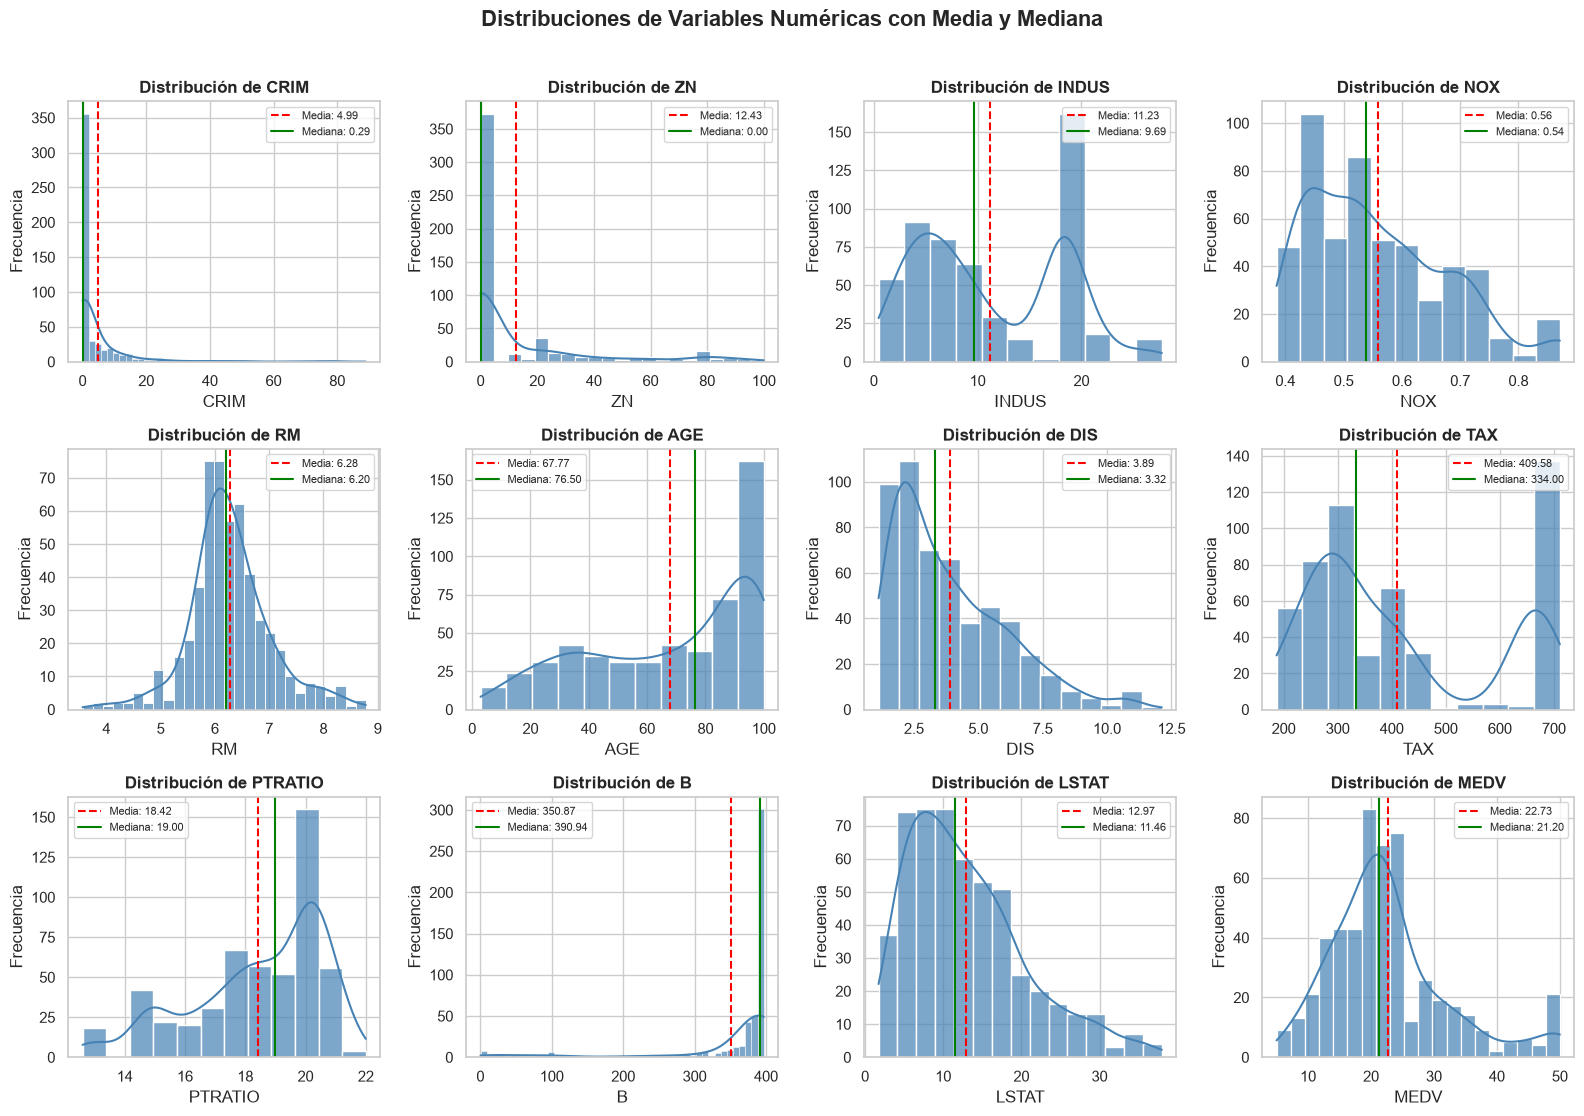

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    sns.histplot(df_casas_limpio[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Líneas de referencia: media y mediana
    media = df_casas_limpio[col].mean()
    mediana = df_casas_limpio[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivamos los ejes basándonos en la nueva cantidad de columnas
for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

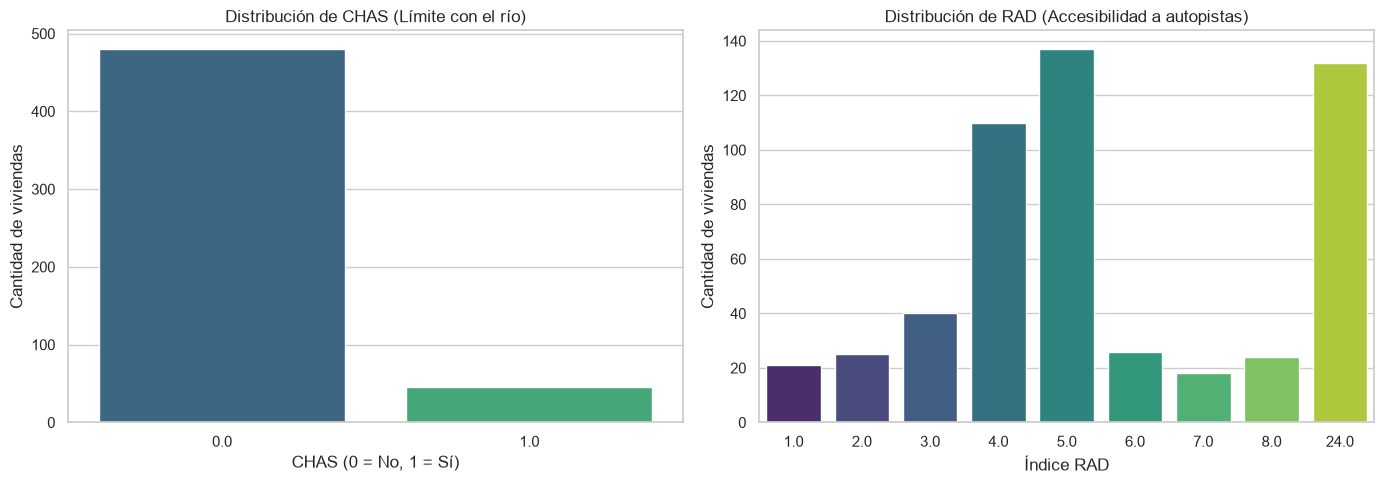

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_casas_limpio, x='CHAS', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de CHAS (Límite con el río)')
axes[0].set_xlabel('CHAS (0 = No, 1 = Sí)')
axes[0].set_ylabel('Cantidad de viviendas')

sns.countplot(data=df_casas_limpio, x='RAD', ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de RAD (Accesibilidad a autopistas)')
axes[1].set_xlabel('Índice RAD')
axes[1].set_ylabel('Cantidad de viviendas')

plt.tight_layout()
plt.show()

### Lectura de los gráficos
Se observa el balance entre categorías de `CHAS` y la distribución de `RAD`, información que usamos más adelante para decidir cómo tratarlas en el escalado.

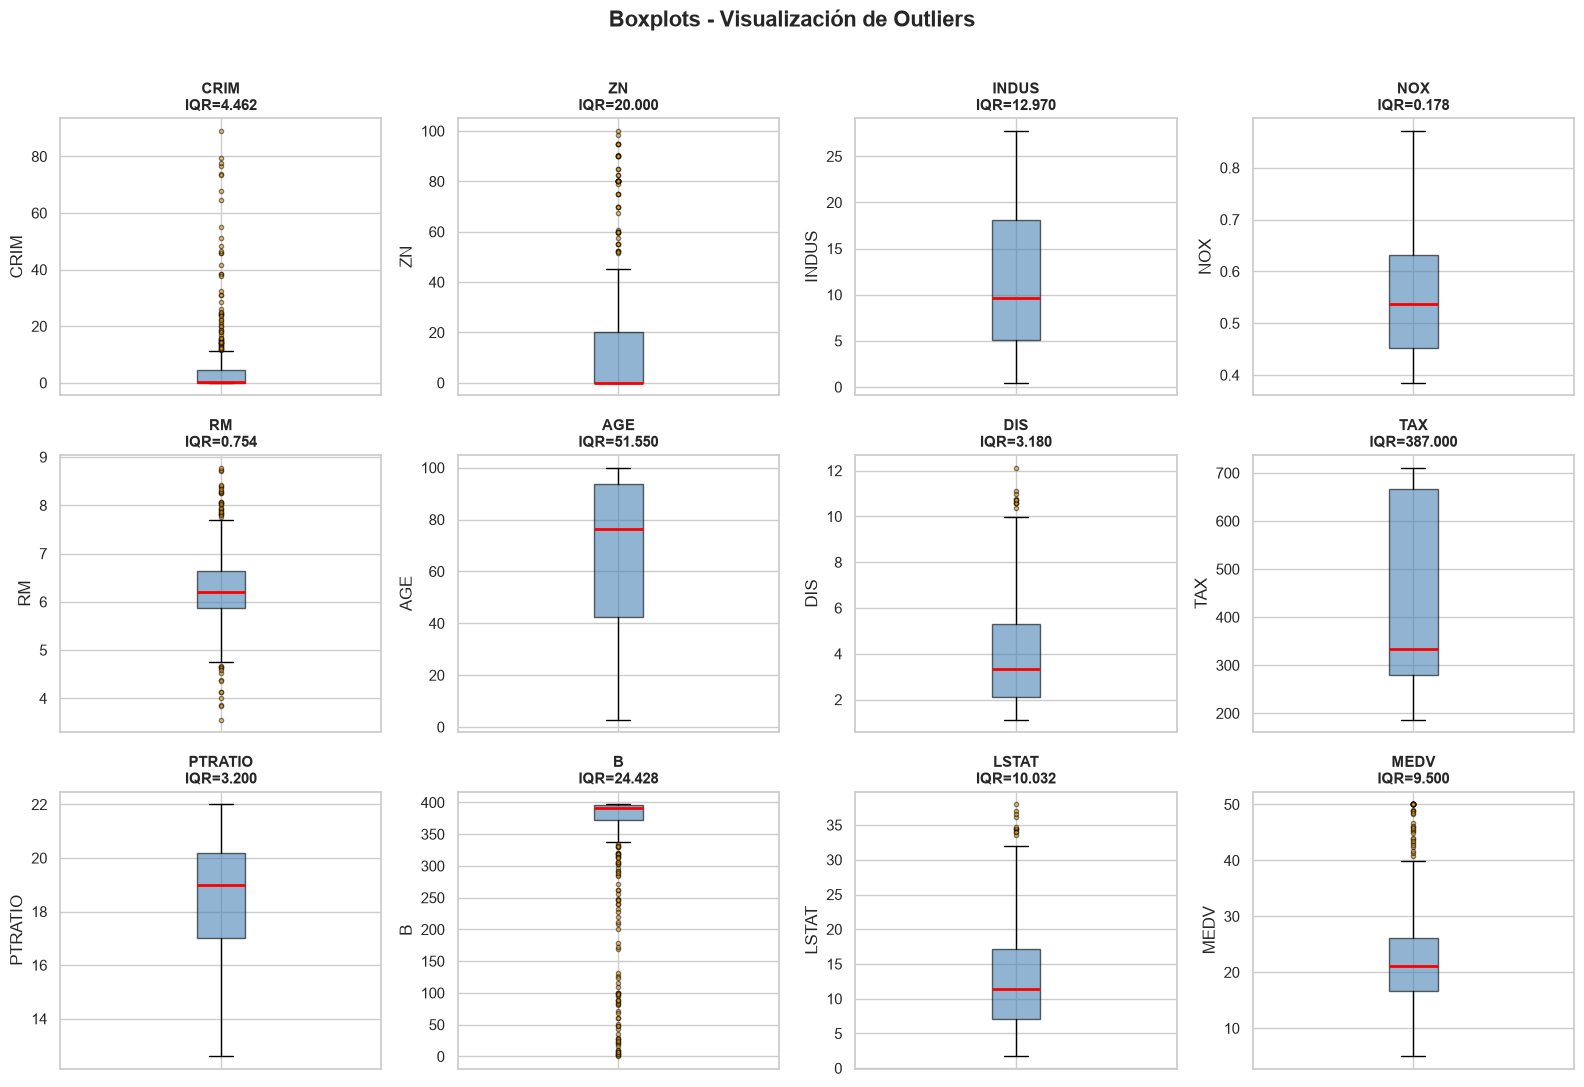

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    datos = df_casas_limpio[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualización de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [18]:
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.4593,0.0000,474.8110,0.0000,No
1,ZN,0.5815,0.0000,212.2087,0.0000,No
2,INDUS,0.9068,0.0000,356.7097,0.0000,No
3,NOX,0.9366,0.0000,37.7544,0.0000,No
4,RM,0.9646,0.0000,26.5557,0.0000,No
5,AGE,0.8942,0.0000,154.8825,0.0000,No
6,DIS,0.9001,0.0000,78.4015,0.0000,No
7,TAX,0.8245,0.0000,295.7152,0.0000,No
8,PTRATIO,0.9073,0.0000,46.5721,0.0000,No
9,B,0.5181,0.0000,279.5886,0.0000,No


Como las variables no son normales, no es apropiado usar el z-score para eliminar outliers; en su lugar usamos el método IQR.

In [19]:
IQR_FACTOR = 1.5

reporte_outliers = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()
    n = len(datos)

    # Metodo IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Metodo IQR')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)']]

Reporte de Outliers: Metodo IQR


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%)
0,CRIM,524,4.4619,-6.6092,11.2382,64,12.2137
1,ZN,523,20.0000,-30.0000,50.0000,54,10.3250
2,INDUS,531,12.9700,-14.3250,37.5550,0,0.0000
3,NOX,526,0.1780,0.1860,0.8980,0,0.0000
4,RM,527,0.7540,4.7455,7.7615,41,7.7799
5,AGE,523,51.5500,-34.9750,171.2250,0,0.0000
6,DIS,529,3.1804,-2.6637,10.0579,10,1.8904
7,TAX,525,387.0000,-301.5000,1246.5000,0,0.0000
8,PTRATIO,525,3.2000,12.2000,25.0000,0,0.0000
9,B,526,24.4275,334.9737,432.6838,87,16.5399


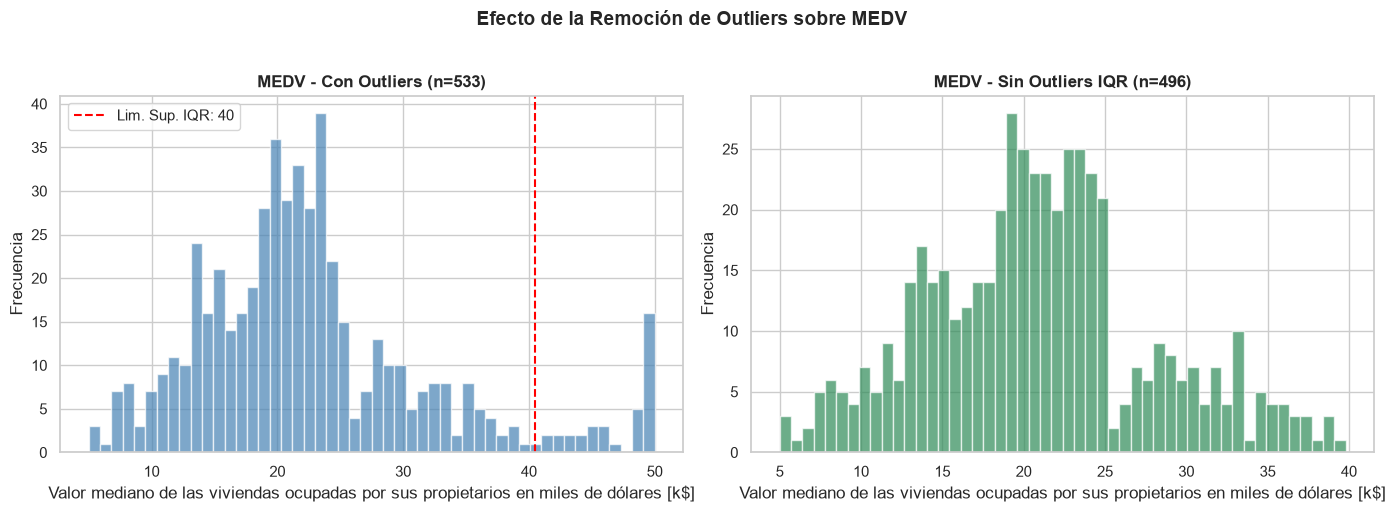

Registros eliminados: 37 (6.94%)


In [20]:
col_ejemplo = 'MEDV'
datos = df_casas_limpio[col_ejemplo].dropna()

# Limites IQR
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers
axes[0].hist(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.0f}')
axes[0].set_title(f'{col_ejemplo} - Con Outliers (n={len(datos)})',
                  fontweight='bold')
axes[0].set_xlabel('Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$]')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin outliers
axes[1].hist(datos_sin_outliers, bins=50, color='seagreen',
             edgecolor='white', alpha=0.7)
axes[1].set_title(f'{col_ejemplo} - Sin Outliers IQR (n={len(datos_sin_outliers)})',
                  fontweight='bold')
axes[1].set_xlabel('Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$]')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Efecto de la Remoción de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Registros eliminados: {len(datos) - len(datos_sin_outliers)} '
      f'({(len(datos) - len(datos_sin_outliers)) / len(datos) * 100:.2f}%)')

In [21]:
matriz=df_casas_limpio.corr(method='pearson')

<Axes: >

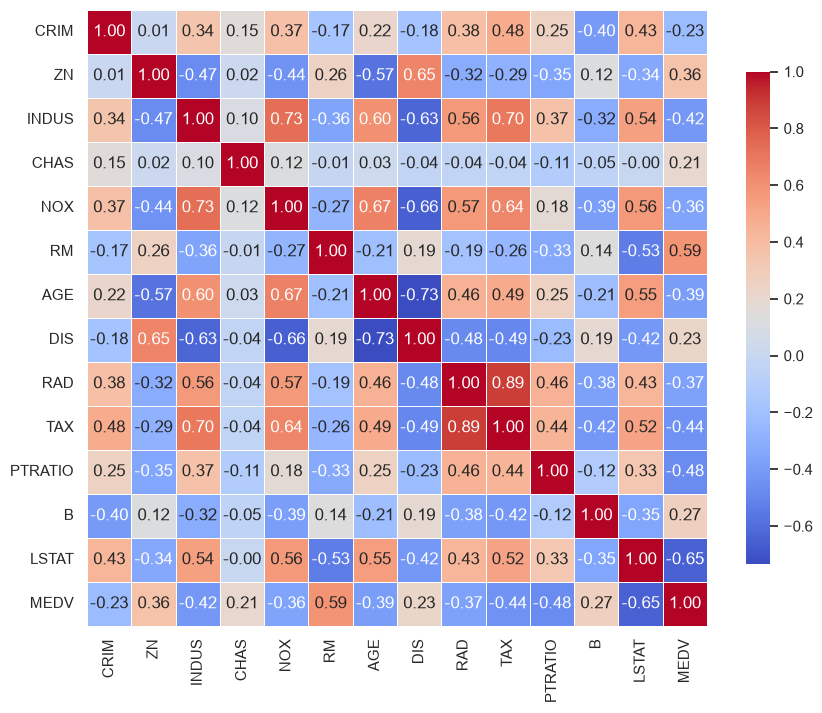

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    data=matriz, 
    annot=True,            # Muestra el valor numérico dentro de cada celda
    fmt=".2f",             # Formato del número (ej. ".2f" para 2 decimales, "d" para enteros)
    cmap="coolwarm",       # Paleta de colores atractiva
    linewidths=0.5,        # Agrega líneas de separación entre las celdas
    linecolor='white',     # Color de las líneas de separación
    cbar_kws={"shrink": .8} # Ajusta el tamaño de la barra de colores lateral
)

## Conclusiones de la Matriz de Correlación

1. Multicolinealidad (El caso de RAD y TAX)
 En el gráfico se observa una correlación altísima de 0.89 entre RAD (accesibilidad a autopistas) y TAX (tasa de impuestos). Aunque parezcan conceptos que no tienen nada que ver, en el contexto geográfico de Boston están ligados: las zonas más urbanizadas y céntricas suelen tener tanto los impuestos más altos como el mayor acceso a las autopistas principales, mientras que los suburbios alejados tienen menos de ambas.

## Análisis de Coherencia de Outliers (CRIM, ZN, B)

El método IQR marca muchos outliers en `CRIM`, `ZN` y `B` que en realidad son la cola larga de variables muy asimétricas, no errores de carga. Para decidir cuáles conservar y cuáles revisar, cada outlier se contrasta contra la relación que la matriz de correlación anterior predice con `MEDV` y con otras variables del mismo dominio: si un outlier rompe la mayoría de esas relaciones esperadas, se marca como incoherente y candidato a revisión manual.

*(Ejecutar el notebook completo — Kernel → Restart & Run All — para generar las salidas de esta sección y las siguientes.)*

In [23]:
def detectar_outliers_iqr(df, columna):
    serie = df[columna].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df_outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)].copy()
    df_outliers['lado'] = np.where(df_outliers[columna] > lim_sup, 'alto', 'bajo')
    return df_outliers, lim_inf, lim_sup

### Función: chequear coherencia

Para los outliers de una columna, evalúa si el valor extremo es coherente con la relación esperada respecto al target y a otras variables relacionadas por dominio (según la matriz de correlación).

- `direccion`: +1 si la columna correlaciona positivo con el target, -1 si correlaciona negativo.
- `relaciones`: diccionario opcional `{variable: signo_esperado}` con otras variables relacionadas por dominio.
- `umbral_fraccion`: proporción mínima de relaciones evaluables que se deben romper para marcar la fila como incoherente.

Cada outlier se compara contra la mediana global de cada variable. Las filas con NaN en la variable comparada no cuentan ni a favor ni en contra: reducen el denominador de la fracción en lugar de bajar el conteo absoluto.

In [24]:
def chequear_coherencia(df, columna, direccion, relaciones=None, target='MEDV',
                         umbral_fraccion=0.5):
    df_outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, columna)
    signo_lado = np.where(df_outliers['lado'] == 'alto', 1, -1)

    def marca_rompe(var, signo_esperado):
        mediana_var = df[var].median(skipna=True)
        diff = df_outliers[var] - mediana_var
        signo_fila = np.sign(diff)
        signo_esperado_fila = signo_lado * signo_esperado
        evaluable = diff.notna() & (signo_fila != 0)
        rompe = evaluable & (np.sign(signo_esperado_fila) != signo_fila)
        return evaluable, rompe

    todas_las_relaciones = [(target, direccion)] + list((relaciones or {}).items())
    n_evaluables = pd.Series(0, index=df_outliers.index)
    n_rotas = pd.Series(0, index=df_outliers.index)
    for var, signo_var in todas_las_relaciones:
        evaluable, rompe = marca_rompe(var, signo_var)
        df_outliers[f'rompe_{var}'] = rompe
        n_evaluables += evaluable.astype(int)
        n_rotas += rompe.astype(int)

    df_outliers['n_evaluables'] = n_evaluables
    df_outliers['n_rotas'] = n_rotas
    df_outliers['fraccion_rota'] = np.where(n_evaluables > 0, n_rotas / n_evaluables, 0.0)

    df_incoherentes = (
        df_outliers[(df_outliers['n_evaluables'] > 0) &
                    (df_outliers['fraccion_rota'] >= umbral_fraccion)]
        .sort_values(['fraccion_rota', 'n_evaluables'], ascending=False)
    )

    print(f"--- {columna} ---")
    print(f"  límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}]  -> {len(df_outliers)} outliers totales")
    print(f"  incoherentes (rompen >={umbral_fraccion*100:.0f}% de lo evaluable): {len(df_incoherentes)}")

    return df_outliers, df_incoherentes

### Función: graficar coherencia

Grafica los outliers de una columna contra `MEDV`, distinguiendo datos normales, outliers coherentes (se conservan) y outliers incoherentes (candidatos a revisión manual).

In [25]:
def graficar_coherencia(df, columna, df_outliers, df_incoherentes, target='MEDV'):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=columna, y=target, color='lightgrey', alpha=0.6,
                     label='Datos normales')

    coherentes = df_outliers.drop(df_incoherentes.index)
    sns.scatterplot(data=coherentes, x=columna, y=target, color='orange', edgecolor='black',
                     label='Outlier coherente (conservar)')

    sns.scatterplot(data=df_incoherentes, x=columna, y=target, color='red', edgecolor='black',
                     s=90, label='Outlier incoherente (revisar)')

    plt.title(f'Coherencia de outliers de {columna} respecto a {target}')
    plt.xlabel(columna)
    plt.ylabel(target)
    plt.legend()
    plt.show()

### Configuración: signos esperados por variable

Los signos salen de la matriz de correlación calculada en la sección anterior:

- **CRIM** correlaciona negativo con `MEDV`, negativo con `RM`, positivo con `LSTAT`.
- **ZN** correlaciona positivo con `MEDV`, negativo con `INDUS`, negativo con `LSTAT`.
- **B** correlaciona positivo con `MEDV`, negativo con `LSTAT`.

In [26]:
config = {
    'CRIM': dict(direccion=-1, relaciones={'RM': -1, 'LSTAT': 1}),
    'ZN':   dict(direccion=+1, relaciones={'INDUS': -1, 'LSTAT': -1}),
    'B':    dict(direccion=+1, relaciones={'LSTAT': -1}),
}

### Ejecutamos el análisis para CRIM, ZN y B

Con `umbral_fraccion=0.5` marcamos como incoherente a la fila que rompe la mayoría de las relaciones que se pudieron evaluar.

--- CRIM ---
  límites IQR: [-6.61, 11.24]  -> 64 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 10


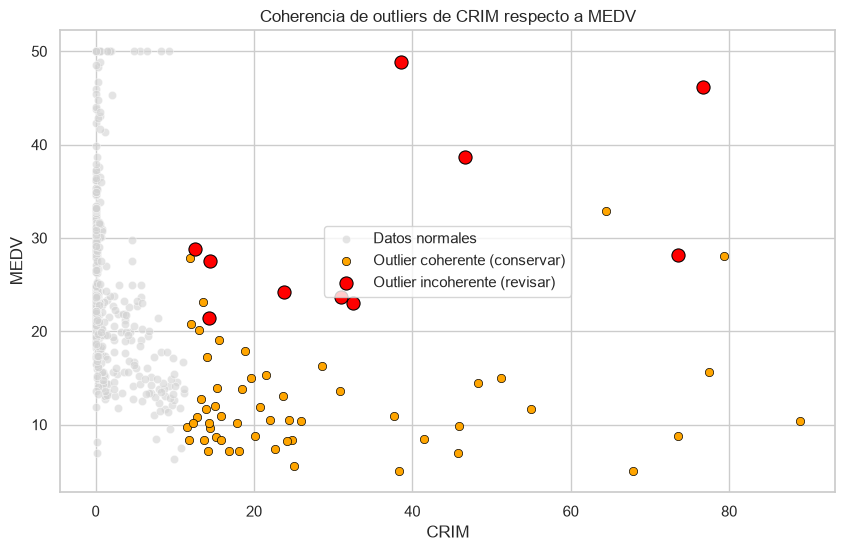

--- ZN ---
  límites IQR: [-30.00, 50.00]  -> 54 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 6


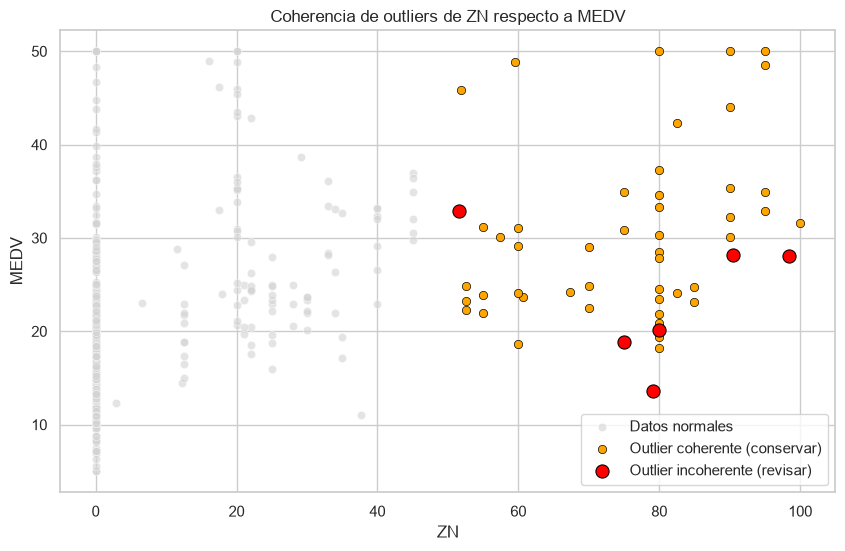

--- B ---
  límites IQR: [334.97, 432.68]  -> 87 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 21


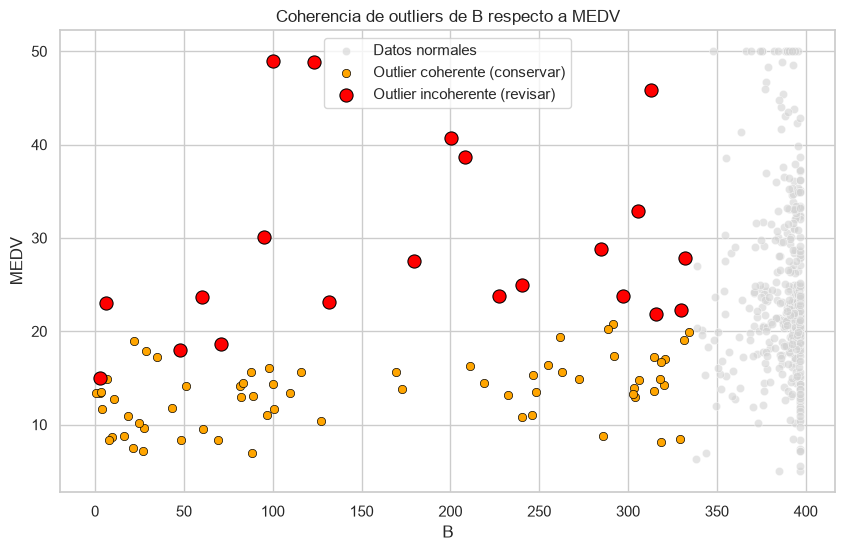

In [27]:
resultados = {}
for col, cfg in config.items():
    outliers, incoherentes = chequear_coherencia(df_casas_limpio, col, **cfg, umbral_fraccion=0.5)
    resultados[col] = (outliers, incoherentes)
    graficar_coherencia(df_casas_limpio, col, outliers, incoherentes)

### Triangulación entre variables

Una fila que rompe el patrón esperado en más de una variable independiente es un candidato más fuerte a revisión manual que una que solo lo rompe en una.

In [28]:
indices = [set(incoh.index) for _, incoh in resultados.values()]
interseccion = set.union(*[
    indices[i] & indices[j]
    for i in range(len(indices)) for j in range(i + 1, len(indices))
])

print('Filas incoherentes en más de una variable:', sorted(interseccion))

cols_mostrar = ['CRIM', 'ZN', 'B', 'RM', 'LSTAT', 'INDUS', 'MEDV']
df_casas_limpio.loc[sorted(interseccion), cols_mostrar]

Filas incoherentes en más de una variable: [14, 23, 264, 298, 316, 458, 520, 554]


,CRIM,ZN,B,RM,LSTAT,INDUS,MEDV
14,30.9865,60.7115,60.1620,NaN,30.4948,8.8272,23.6754
23,73.6057,90.4347,NaN,8.0501,NaN,12.7403,28.1301
264,38.6081,59.5613,123.4545,3.8395,3.3899,15.5515,48.8545
298,14.4383,0.0000,179.3600,6.8520,19.7800,18.1000,27.5000
316,46.6368,29.0858,208.3193,4.5902,9.7974,23.6764,38.7155
458,12.5105,11.6104,284.7875,7.9491,27.7894,14.4042,28.8124
520,64.4546,51.5727,305.3963,5.6565,33.9643,12.8320,32.8579
554,32.5040,6.5286,6.2671,4.0166,7.0340,8.9373,23.0288


## Separación en Train/Test e Imputación con KNNImputer

Separamos primero `X`/`y` y hacemos el split para evitar fuga de datos, y recién después eliminamos las filas trianguladas como incoherentes — y solo si cayeron en train. Nunca se eliminan filas de test: debe reflejar los datos reales, con sus casos difíciles incluidos, tal como el modelo los va a enfrentar en producción.

In [29]:
from sklearn.model_selection import train_test_split

X = df_casas_limpio.drop(columns='MEDV')
y = df_casas_limpio['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

filas_a_eliminar = sorted(interseccion)
filas_en_train = [i for i in filas_a_eliminar if i in X_train.index]
filas_en_test = [i for i in filas_a_eliminar if i in X_test.index]

print(f'Se eliminan de train: {filas_en_train}')
print(f'Se conservan en test (aunque estén en la lista): {filas_en_test}')

X_train = X_train.drop(index=filas_en_train)
y_train = y_train.drop(index=filas_en_train)

Se eliminan de train: [14, 23, 316, 520, 554]
Se conservan en test (aunque estén en la lista): [264, 298, 458]


### Escalado con RobustScaler

Usamos `RobustScaler` (mediana e IQR) en lugar de `StandardScaler` porque `CRIM`, `ZN` y `B` conservan outliers legítimos que decidimos no eliminar. El escalador se ajusta (`fit`) solo con train y se aplica (`transform`) a test, sin que test participe del cálculo.

In [30]:
from sklearn.preprocessing import RobustScaler

columnas_continuas = [c for c in X_train.columns if c not in ['CHAS', 'RAD']]

scaler = RobustScaler()
X_train_esc = X_train.copy()
X_train_esc[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])

X_test_esc = X_test.copy()
X_test_esc[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

### Efecto del escalado sobre las distribuciones

Comparamos las columnas continuas de train antes y después de aplicar `RobustScaler`, para verificar visualmente que las medianas quedan centradas y las escalas se vuelven comparables entre variables.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
X_train[columnas_continuas].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red'))
axes[0].set_title('Antes de Escalar', fontweight='bold')
axes[0].set_ylabel('Valor original')
axes[0].tick_params(axis='x', rotation=45)

# Despues
X_train_esc[columnas_continuas].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red'))
axes[1].set_title('Despues de Escalar (RobustScaler)', fontweight='bold')
axes[1].set_ylabel('Valor escalado')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Efecto del Escalado sobre las Distribuciones (Train)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Método del Codo para Elegir `n_neighbors` (KNNImputer)

Tomamos las filas de train sin ningún NaN, les borramos artificialmente una fracción de valores conocidos, las imputamos con distintos `k` y medimos el error de reconstrucción (NRMSE) sobre las celdas enmascaradas. Se repite con varias máscaras aleatorias y se promedia. Todo esto se hace solo con train: elegir `k` mirando test sería la misma fuga de datos que vimos con el escalador.

In [31]:
from sklearn.impute import KNNImputer

### Función: enmascarar y medir

Enmascara aleatoriamente una fracción de las celdas, imputa con `KNNImputer(n_neighbors=k)` y devuelve el NRMSE de la reconstrucción, calculado solo sobre las celdas enmascaradas (normalizado por el desvío de cada columna para poder promediar entre columnas de escalas distintas).

In [32]:
def enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng):
    mascara = rng.random(datos_verdad.shape) < fraccion_mascara
    datos_enmascarados = datos_verdad.copy()
    datos_enmascarados[mascara] = np.nan

    imputer = KNNImputer(n_neighbors=k)
    reconstruido = imputer.fit_transform(datos_enmascarados)

    std_cols = datos_verdad.std(axis=0)
    error = (reconstruido[mascara] - datos_verdad[mascara]) ** 2
    std_expandido = np.tile(std_cols, (datos_verdad.shape[0], 1))[mascara]
    return np.sqrt(np.mean(error / (std_expandido ** 2 + 1e-12)))

### Función: curva del codo

Repite el experimento de enmascaramiento `n_repeticiones` veces para cada valor de `k`, y devuelve una tabla con la media y el desvío del NRMSE por `k`. Más repeticiones implican una curva más estable, con menos ruido.

In [33]:
def curva_del_codo(datos_verdad, ks, n_repeticiones=15, fraccion_mascara=0.05):
    filas = []
    for k in ks:
        errores = []
        for rep in range(n_repeticiones):
            rng = np.random.default_rng(rep)
            errores.append(enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng))
        filas.append({
            'k': k,
            'nrmse_medio': np.mean(errores),
            'nrmse_std': np.std(errores),
        })
    return pd.DataFrame(filas)

### Función: graficar el codo

NRMSE promedio (± desvío) vs. `k`, para ubicar el codo a ojo.

In [34]:
def graficar_codo(tabla_resultados):
    plt.figure(figsize=(9, 5))
    plt.errorbar(
        tabla_resultados['k'], tabla_resultados['nrmse_medio'],
        yerr=tabla_resultados['nrmse_std'], marker='o', capsize=3
    )
    plt.title('Método del codo para elegir n_neighbors (KNNImputer)')
    plt.xlabel('n_neighbors (k)')
    plt.ylabel('NRMSE promedio (experimento de enmascaramiento)')
    plt.grid(alpha=0.3)
    plt.show()

### Ejecutamos el experimento

Usamos solo las filas completas (sin NaN) de `X_train_esc` — nunca se toca test para elegir el hiperparámetro.

In [35]:
completas = X_train_esc[columnas_continuas].dropna().copy()
print(f'Filas completas en train usadas para el experimento: {completas.shape[0]}')

datos_verdad = completas.to_numpy()
ks_a_probar = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]

tabla = curva_del_codo(datos_verdad, ks_a_probar, n_repeticiones=15, fraccion_mascara=0.05)
tabla

Filas completas en train usadas para el experimento: 406


,k,nrmse_medio,nrmse_std
0,1,0.7222,0.1284
1,2,0.6516,0.0853
2,3,0.6109,0.0669
3,5,0.6011,0.0693
4,7,0.5971,0.0634
5,10,0.6028,0.0571
6,15,0.6175,0.0506
7,20,0.6281,0.0478
8,25,0.6353,0.0478
9,30,0.6412,0.0474


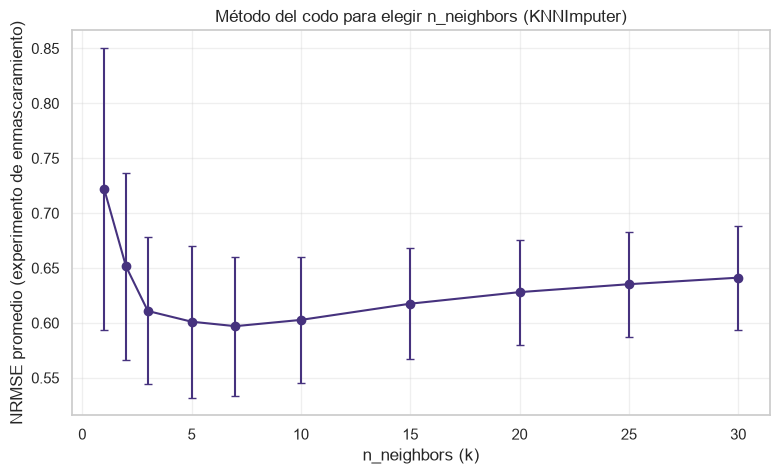

In [36]:
graficar_codo(tabla)

### Interpretamos el resultado

El `k` con menor NRMSE promedio es el mínimo exacto de la curva, pero no necesariamente es "el codo": el codo es el punto donde la curva deja de bajar fuerte, normalmente un poco antes del mínimo exacto. Si varios valores de `k` quedan dentro del mismo desvío estándar entre sí, conviene priorizar el más chico de esa zona plana (más conservador con la varianza original de los datos).

In [37]:
k_minimo = int(tabla.loc[tabla['nrmse_medio'].idxmin(), 'k'])
print(f'k con menor NRMSE promedio: {k_minimo}')

k con menor NRMSE promedio: 7


## Imputación Final con KNNImputer

Con el `k` elegido según el método del codo, imputamos los valores faltantes de las columnas continuas ya escaladas.

In [38]:
imputer = KNNImputer(n_neighbors=k_minimo)

X_train_imp = X_train_esc.copy()
X_train_imp[columnas_continuas] = imputer.fit_transform(X_train_esc[columnas_continuas])

X_test_imp = X_test_esc.copy()
X_test_imp[columnas_continuas] = imputer.transform(X_test_esc[columnas_continuas])

print('Nulos restantes en train:', X_train_imp[columnas_continuas].isnull().sum().sum())
print('Nulos restantes en test:', X_test_imp[columnas_continuas].isnull().sum().sum())

Nulos restantes en train: 0
Nulos restantes en test: 0


## Resumen del Pipeline de Preprocesamiento

1. Eliminamos las filas con `MEDV` nulo y las que tenían 50% o más de datos faltantes.
2. Corregimos los valores inválidos de `RAD`.
3. Analizamos outliers por IQR y verificamos su coherencia contra la matriz de correlación para `CRIM`, `ZN` y `B`.
4. Separamos train/test antes de tocar escalado o imputación, para evitar fuga de datos.
5. Eliminamos de train (nunca de test) las filas trianguladas como incoherentes.
6. Escalamos con `RobustScaler`, ajustado solo con train.
7. Elegimos `n_neighbors` para `KNNImputer` con el método del codo, y lo aplicamos para imputar los nulos restantes.